# Screening internal tides with HRET

This notebook compares SSHA wavenumber spectra with and wothout HRET internal tides being included. Spectra segements where internal waves represent too much energy in the 10 to 50km wavelengths range are removed. Maps similar to the ones from Global_SSH_spectra.ipynb are plotted for comparison.

In [1]:

import glob
import os
import warnings
from collections import defaultdict
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe


from swot_analysis import compute_pass_spectra
from swot_analysis import load_swot_l2_expert 

In [2]:
# ── Input files ───────────────────────────────────────────────────────────────
DATA_DIR        = '/Volumes/PortableSSD/diags_2024/'
FILENAME_ITIDE  = "swot_segments2D_500km_demean.nc"
FILENAME_NOTIDE = "swot_segments2D_500km_notide_demean.nc"

# ── Region of interest ────────────────────────────────────────────────────────
LAT_MIN, LAT_MAX = -60.0,60.0
LON_MIN, LON_MAX = 0.0,360.0

# ── File parameters ───────────────────────────────────────────────────────
SEGMENT_LENGTH_KM = 500.0
BOX_DEG           = 2.0

In [3]:
def build_box_dataset(ds_segments: xr.Dataset,
                      box_deg: float = 2.0,
                      min_sampling_fraction: float = 0.5) -> xr.Dataset:
    from collections import defaultdict
    lat     = ds_segments['lat_mean'].values
    lon     = ds_segments['lon_mean'].values
    lat_idx = np.floor(lat / box_deg).astype(int)
    lon_idx = np.floor(lon / box_deg).astype(int)
    box_to_segs = defaultdict(list)
    for i, key in enumerate(zip(lat_idx, lon_idx)):
        box_to_segs[key].append(i)
    psd_all    = ds_segments['psd'].values
    wavenumber = ds_segments['wavenumber'].values
    rows_lat, rows_lon, rows_n, rows_psd = [], [], [], []
    for (li, loi), idxs in sorted(box_to_segs.items()):
        rows_psd.append(np.nanmean(psd_all[idxs, :], axis=0))
        rows_n.append(len(idxs))
        rows_lat.append((li  + 0.5) * box_deg)
        rows_lon.append((loi + 0.5) * box_deg)
    n_segments = np.array(rows_n)
    n_max      = n_segments.max()
    keep       = n_segments >= min_sampling_fraction * n_max
    psd_stack  = np.stack(rows_psd, axis=0)
    lat_mean   = np.array(rows_lat)
    lon_mean   = np.array(rows_lon)
    return xr.Dataset(
        data_vars=dict(
            mean_psd=(['box', 'wavenumber'], psd_stack[keep],
                      {'long_name': 'Box-mean SSH(A) PSD', 'units': 'm^2 / (cycles/km)'}),
            n_segments=(['box'], n_segments[keep]),
            sampling_fraction=(['box'], n_segments[keep] / n_max),
        ),
        coords=dict(wavenumber=('wavenumber', wavenumber, {'units': 'cycles/km'}),
            box=('box', np.arange(keep.sum())),
            lat_mean=('box', lat_mean[keep], {'units': 'degrees_north'}),
            lon_mean=('box', lon_mean[keep], {'units': 'degrees_east'}),
        ),
        attrs=dict(box_size_deg=box_deg,
                   min_sampling_fraction=min_sampling_fraction),
    )

In [4]:
ds_itide = xr.open_dataset(DATA_DIR+FILENAME_ITIDE)
ds_notide = xr.open_dataset(DATA_DIR+FILENAME_NOTIDE)

print(f'Segment dataset: {ds_itide.sizes}')
print(f'Segment dataset: {ds_notide.sizes}')

#Building boxes:
boxes_itide = build_box_dataset(ds_itide, box_deg=BOX_DEG,min_sampling_fraction=0.15)
boxes_notide = build_box_dataset(ds_notide, box_deg=BOX_DEG,min_sampling_fraction=0.15)

Segment dataset: Frozen({'segment': 706859, 'wavenumber': 125})
Segment dataset: Frozen({'segment': 706859, 'wavenumber': 125})


## Global mapping

In [5]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
import cmocean

def plot_box(var: np.array, lon: np.array, lat: np.array,
             box_deg: float = None,
             projection: ccrs = ccrs.Robinson(), cmap: str = "viridis",
             figsize: tuple = (14, 7), fig = None, ax = None,
             title: str = "Number of observations per box", label: str = "Number of observations",
             norm: norm = None, vmin: float = None, vmax: float = None
            ):
    mask = np.isfinite(var)
    lon = lon[mask]
    lat = lat[mask]
    var = var[mask]

    # Infer box size from the spacing of box centers if not given
    if box_deg is None:
        lat_diffs = np.diff(np.unique(np.round(lat, 6)))
        lon_diffs = np.diff(np.unique(np.round(lon, 6)))
        box_deg = np.min(np.concatenate([lat_diffs, lon_diffs]))

    # Reconstruct the regular grid of box centers
    lat_centers = np.arange(lat.min(), lat.max() + box_deg, box_deg)
    lon_centers = np.arange(lon.min(), lon.max() + box_deg, box_deg)

    lat_idx = np.round((lat - lat_centers[0]) / box_deg).astype(int)
    lon_idx = np.round((lon - lon_centers[0]) / box_deg).astype(int)

    grid = np.full((lat_centers.size, lon_centers.size), np.nan)
    grid[lat_idx, lon_idx] = var

    # pcolormesh wants cell edges, not centers
    lat_edges = np.concatenate([lat_centers - box_deg / 2, [lat_centers[-1] + box_deg / 2]])
    lon_edges = np.concatenate([lon_centers - box_deg / 2, [lon_centers[-1] + box_deg / 2]])
    if ax==None:
        fig = plt.figure(figsize=figsize)
        ax = plt.axes(projection=projection)
    ax.set_global()
    ax.add_feature(cfeature.LAND, facecolor="0.9", edgecolor="none")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, linestyle="--", alpha=0.5)

    gl.top_labels = False
    gl.right_labels = False
    gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 60))
    gl.ylocator = mticker.FixedLocator(np.arange(-60, 61, 30))
    gl.xlabel_style = {"size": 10, "color": "black"}
    gl.ylabel_style = {"size": 10, "color": "black"}

    if norm is not None:
        sc = ax.pcolormesh(lon_edges, lat_edges, grid,
                            cmap=cmap, shading='flat',
                            transform=ccrs.PlateCarree(), norm=norm)
    else:
        if vmin is None:
            vmin, vmax = np.nanmin(var), np.nanmax(var)

        sc = ax.pcolormesh(lon_edges, lat_edges, grid,
                            cmap=cmap, shading='flat',
                            transform=ccrs.PlateCarree(), vmin=vmin, vmax=vmax)

    cb = plt.colorbar(sc, ax=ax, shrink=0.7, pad=0.03)
    cb.set_label(label)
    ax.set_title(title)

    return fig, ax

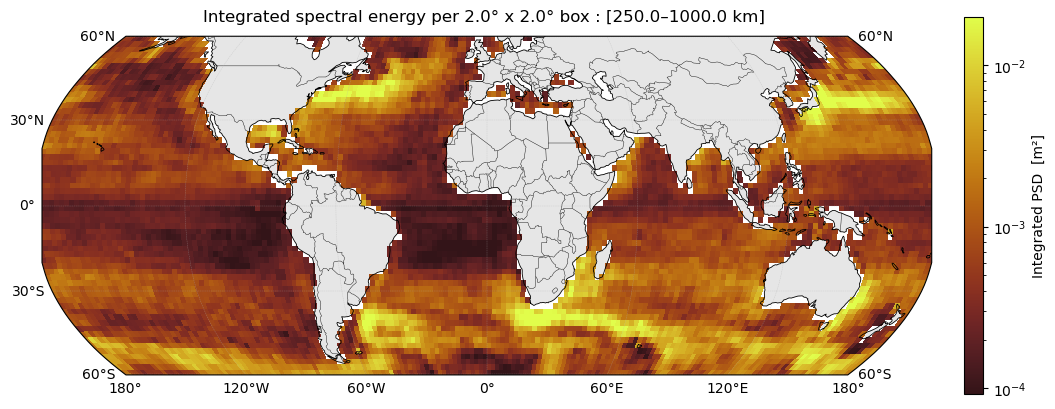

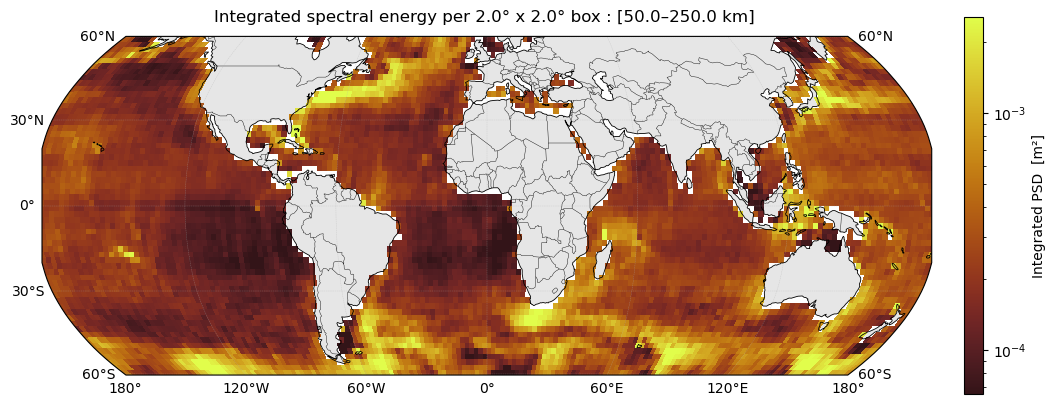

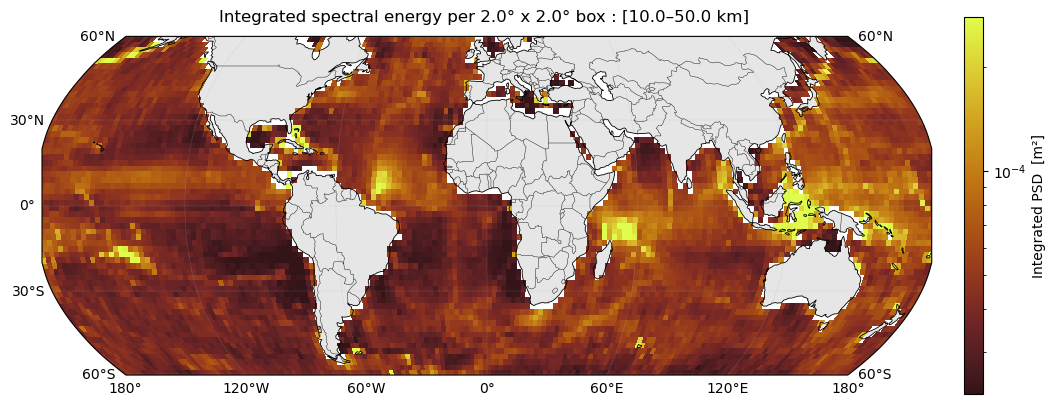

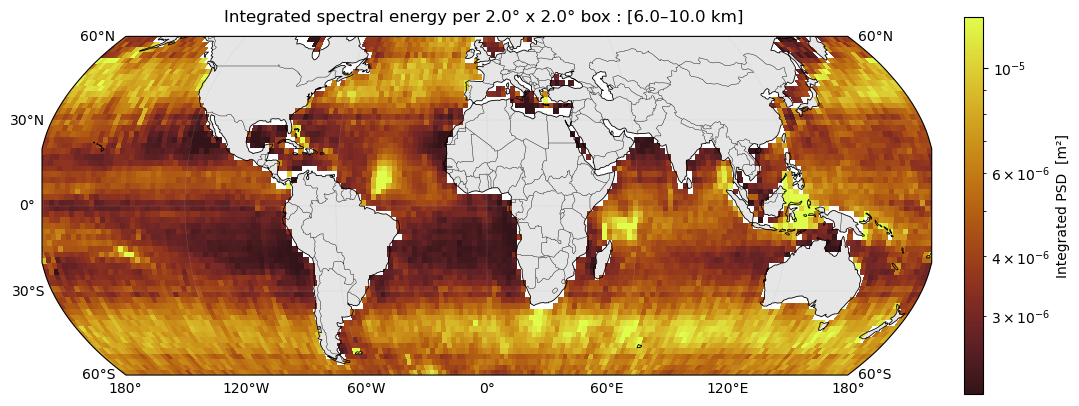

In [6]:
# Integrate the mean PSD over different wavenumber bands
k_min,k_max = [1/1000,1/250,1/50,1/10], [1/250,1/50,1/10,1/6] # /km
for K_MIN,K_MAX in zip(k_min,k_max):
    energy = boxes_itide.mean_psd.sel(wavenumber=slice(K_MIN,K_MAX)).integrate('wavenumber')
    fig, ax = plot_box(energy,boxes_itide["lon_mean"].values,boxes_itide["lat_mean"].values,
                       cmap=cmocean.cm.solar
                       , title=f"Integrated spectral energy per {BOX_DEG:.1f}° x {BOX_DEG:.1f}° box : [{1/K_MAX:.1f}–{1/K_MIN:.1f} km] ",
                       label='Integrated PSD  [m²]',
                      norm=mcolors.LogNorm(vmin=np.nanpercentile(energy, 1),
                                           vmax=np.nanpercentile(energy, 99)))
    ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())
    plt.show()

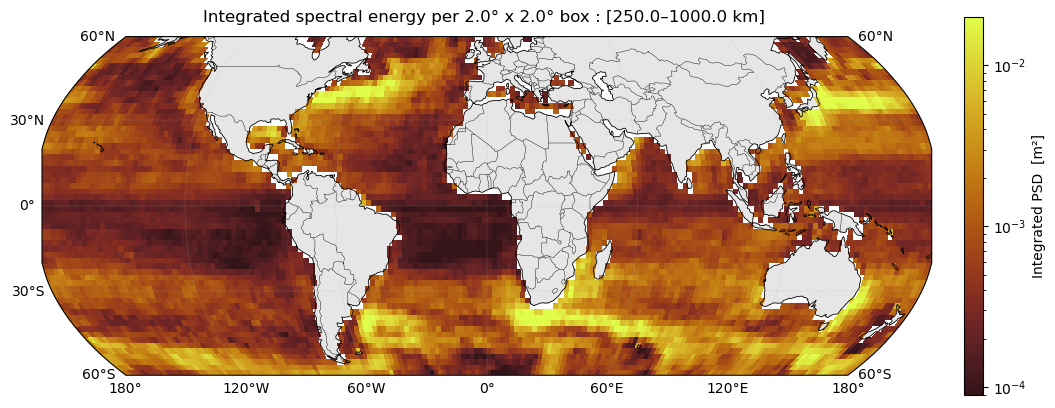

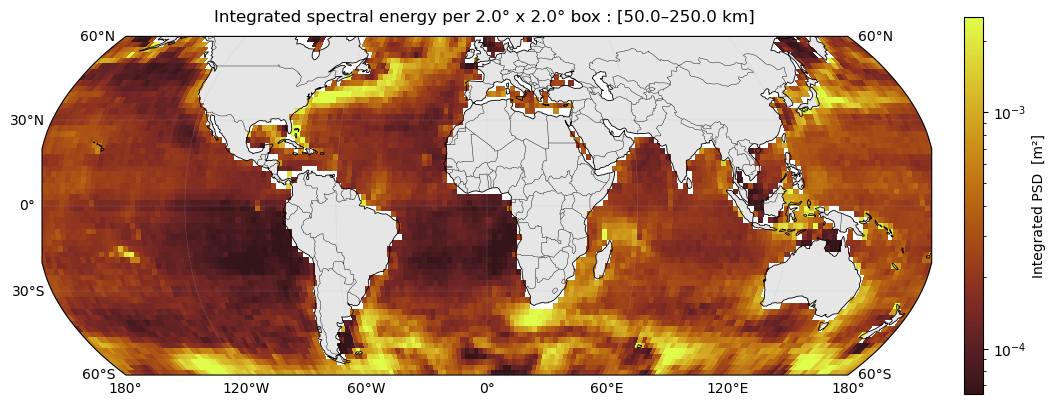

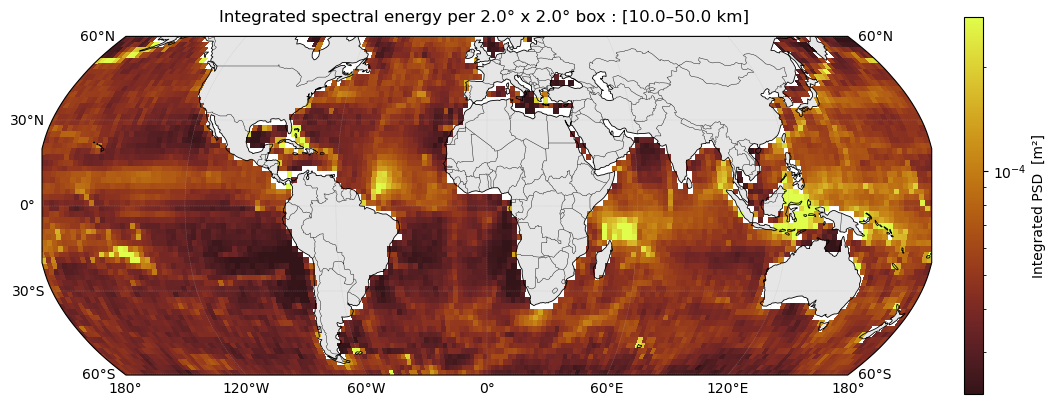

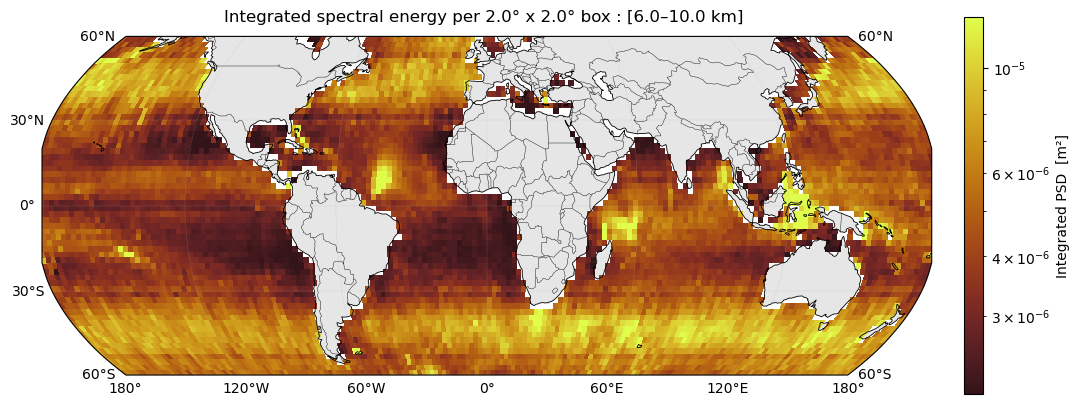

In [7]:
# Integrate the mean PSD over different wavenumber bands, no itide
k_min,k_max = [1/1000,1/250,1/50,1/10], [1/250,1/50,1/10,1/6] # /km
for K_MIN,K_MAX in zip(k_min,k_max):
    energy = boxes_notide.mean_psd.sel(wavenumber=slice(K_MIN,K_MAX)).integrate('wavenumber')
    fig, ax = plot_box(energy,boxes_notide["lon_mean"].values,boxes_notide["lat_mean"].values,
                       cmap=cmocean.cm.solar
                       , title=f"Integrated spectral energy per {BOX_DEG:.1f}° x {BOX_DEG:.1f}° box : [{1/K_MAX:.1f}–{1/K_MIN:.1f} km] ",
                       label='Integrated PSD  [m²]',
                      norm=mcolors.LogNorm(vmin=np.nanpercentile(energy, 1),
                                           vmax=np.nanpercentile(energy, 99)))
    ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())
    plt.show()

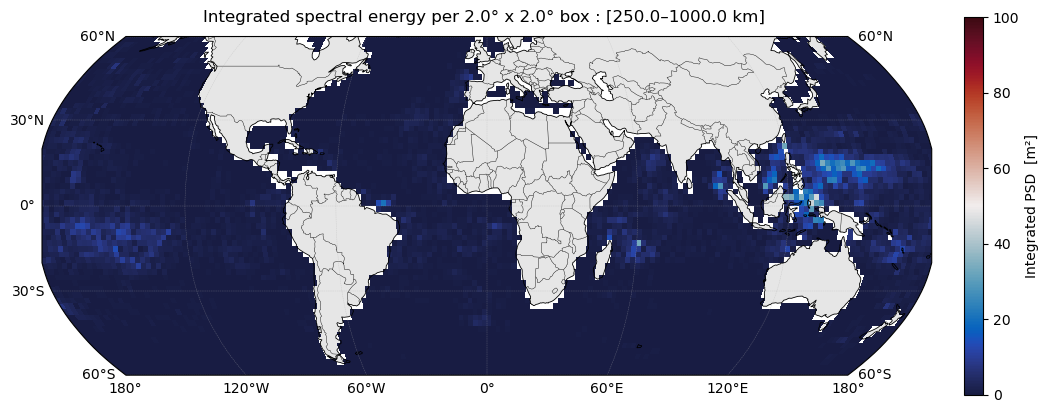

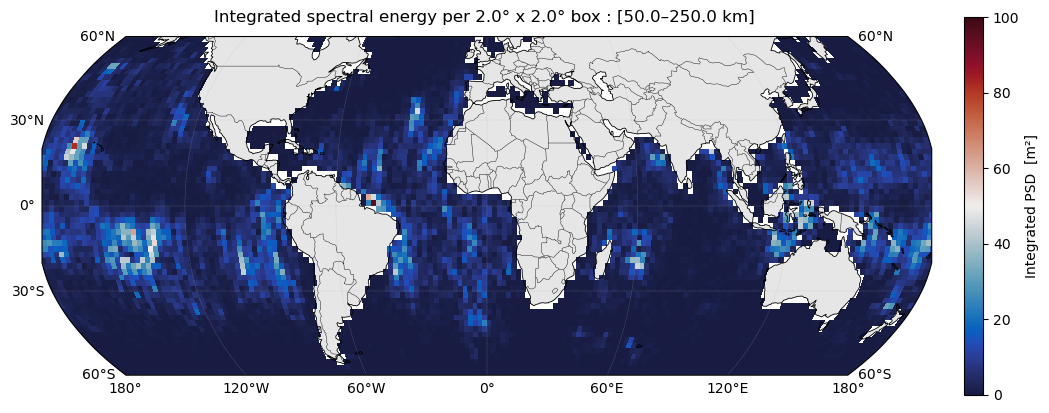

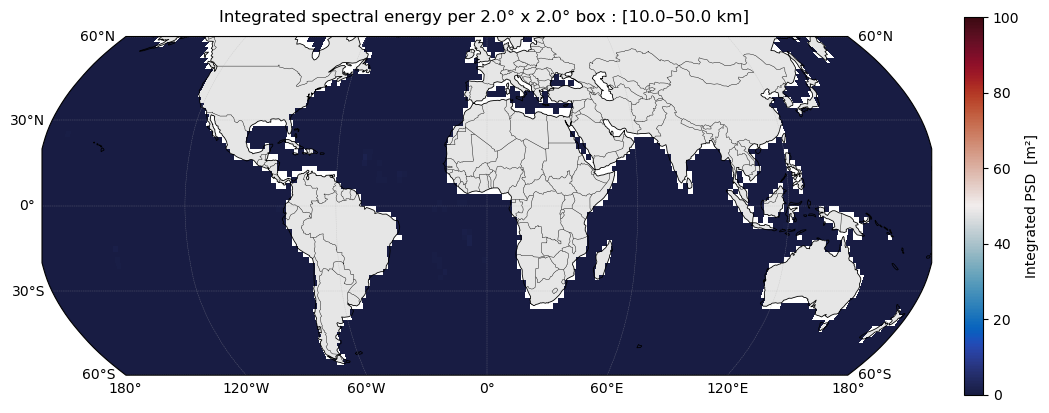

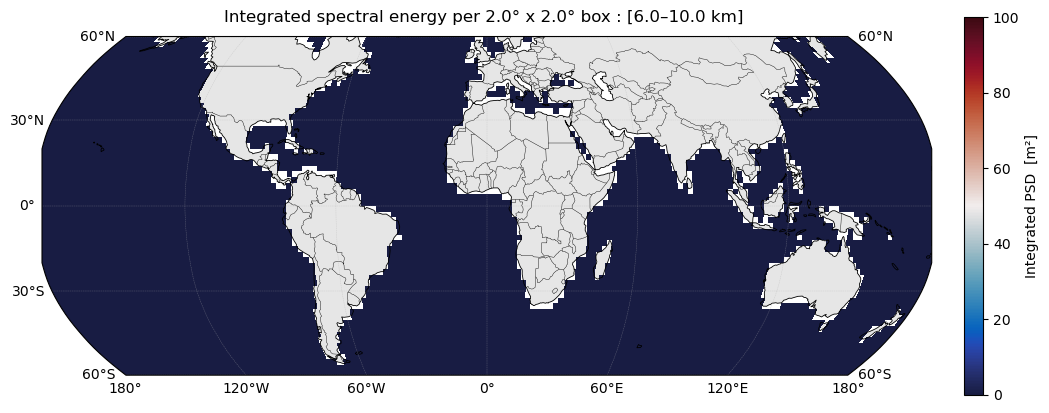

In [8]:
# Integrate the mean PSD over different wavenumber bands, no itide
k_min,k_max = [1/1000,1/250,1/50,1/10], [1/250,1/50,1/10,1/6] # /km
for K_MIN,K_MAX in zip(k_min,k_max):
    energy_itide = boxes_itide.mean_psd.sel(wavenumber=slice(K_MIN,K_MAX)).integrate('wavenumber')
    energy = boxes_notide.mean_psd.sel(wavenumber=slice(K_MIN,K_MAX)).integrate('wavenumber')
    fig, ax = plot_box(np.abs(energy_itide-energy)/energy*100,boxes_notide["lon_mean"].values,boxes_notide["lat_mean"].values,
                       cmap=cmocean.cm.balance,
                       title=f"Integrated spectral energy per {BOX_DEG:.1f}° x {BOX_DEG:.1f}° box : [{1/K_MAX:.1f}–{1/K_MIN:.1f} km] ",
                       label='Integrated PSD  [m²]',
                      vmin=0, vmax=100)
    ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())
    plt.show()

## Separation scales

In [9]:
import numpy as np
import xarray as xr
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d


def estimate_separation_scale_adaptive(ds_box: xr.Dataset,
                                        low_k_band: tuple,
                                        high_k_band: tuple,
                                        smooth_window: int = 7,
                                        polyorder: int = 2,
                                        search_range: tuple = None,
                                        n_interp: int = 200,
                                        verbose: bool = False) -> xr.Dataset:
    """
    Non-parametric separation scale using an adaptive (per-box) slope
    threshold, calibrated to each spectrum's own mesoscale (low-k, steep)
    and sub-mesoscale (high-k, shallower) plateau slopes, instead of a
    fixed universal reference slope like -2.

    Physical convention: mesoscale (low-k) is expected to be steeper
    (more negative slope) than sub-mesoscale (high-k), consistent with
    the transition from geostrophic/QG turbulence (~ -5 to -11/3) to a
    shallower sub-mesoscale regime (~ -2 to -5/3).

    Parameters
    ----------
    low_k_band, high_k_band : tuple(float, float)
        Wavenumber ranges (cycles/km) used to estimate the plateau slope
        on each side of the transition, well away from the break itself.
    smooth_window, polyorder : SG smoothing parameters for the local-slope
        curve used to locate the crossing.
    search_range : tuple(float, float), optional
        Restrict the crossing search to this wavenumber range (defaults
        to the union of low_k_band and high_k_band).
    """
    wavenumber = ds_box['wavenumber'].values
    psd_all    = ds_box['mean_psd'].values
    n_boxes    = psd_all.shape[0]

    k_valid = wavenumber > 0
    wavenumber = wavenumber[k_valid]
    psd_all = psd_all[:, k_valid]
    log_k_orig = np.log10(wavenumber)

    if smooth_window % 2 == 0:
        smooth_window += 1

    log_k_uniform = np.linspace(log_k_orig.min(), log_k_orig.max(), n_interp)
    dlogk = log_k_uniform[1] - log_k_uniform[0]

    if search_range is None:
        k_lo = low_k_band[0]
        k_hi = high_k_band[1]
    else:
        k_lo, k_hi = search_range
    search_mask = (10**log_k_uniform >= k_lo) & (10**log_k_uniform <= k_hi)

    separation_k    = np.full(n_boxes, np.nan)
    slope_low_all   = np.full(n_boxes, np.nan)
    slope_high_all  = np.full(n_boxes, np.nan)
    threshold_used  = np.full(n_boxes, np.nan)

    for i in range(n_boxes):
        p = psd_all[i]
        valid = np.isfinite(p) & (p > 0)
        if valid.sum() < smooth_window:
            continue

        k = wavenumber[valid]
        logp = np.log10(p[valid])

        # --- Plateau slopes: simple linear fit on RAW (unsmoothed)
        # points within each band, so no window-straddling bias here ---
        low_mask = (k >= low_k_band[0]) & (k <= low_k_band[1])
        high_mask = (k >= high_k_band[0]) & (k <= high_k_band[1])

        if low_mask.sum() < 3 or high_mask.sum() < 3:
            if verbose:
                print(f"Box {i}: not enough points in plateau bands "
                      f"(low={low_mask.sum()}, high={high_mask.sum()}), skipping.")
            continue

        slope_low = np.polyfit(np.log10(k[low_mask]), logp[low_mask], 1)[0]
        slope_high = np.polyfit(np.log10(k[high_mask]), logp[high_mask], 1)[0]
        slope_low_all[i] = slope_low
        slope_high_all[i] = slope_high

        # Adaptive threshold: midpoint between the two plateau slopes
        threshold = 0.5 * (slope_low + slope_high)
        threshold_used[i] = threshold

        # Expect mesoscale (low-k) STEEPER than sub-mesoscale (high-k),
        # i.e. slope_low < slope_high (more negative = steeper).
        if slope_low >= slope_high:
            if verbose:
                print(f"Box {i}: low-k slope ({slope_low:.2f}) not steeper "
                      f"than high-k slope ({slope_high:.2f}) — no clear "
                      f"mesoscale-to-submesoscale steepening-to-shallowing "
                      f"transition, skipping.")
            continue

        # --- Local slope curve via SG, same as before ---
        interp_fn = interp1d(np.log10(k), logp, bounds_error=False, fill_value=np.nan)
        logp_uniform = interp_fn(log_k_uniform)
        valid_u = ~np.isnan(logp_uniform)
        if valid_u.sum() < smooth_window:
            continue

        slope_curve = np.full(n_interp, np.nan)
        win = min(smooth_window, valid_u.sum() if valid_u.sum() % 2 == 1 else valid_u.sum() - 1)
        if win <= polyorder:
            continue
        slope_curve[valid_u] = savgol_filter(logp_uniform[valid_u], window_length=win,
                                              polyorder=polyorder, deriv=1, delta=dlogk)

        mask = search_mask & valid_u
        idxs = np.where(mask)[0]
        if len(idxs) < 2:
            continue

        diff = slope_curve[idxs] - threshold
        sign_change = np.where(np.diff(np.sign(diff)) != 0)[0]
        if len(sign_change) == 0:
            if verbose:
                print(f"Box {i}: slope never crosses adaptive threshold "
                      f"{threshold:.2f}.")
            continue

        j = sign_change[0]
        frac = -diff[j] / (diff[j + 1] - diff[j])
        i1, i2 = idxs[j], idxs[j + 1]
        log_k_cross = log_k_uniform[i1] + frac * (log_k_uniform[i2] - log_k_uniform[i1])
        separation_k[i] = 10 ** log_k_cross

    ds_out = ds_box.copy()
    ds_out['separation_wavenumber'] = (
        ['box'], separation_k,
        {'long_name': 'Wavenumber of adaptive-threshold slope crossing '
                       '(mesoscale-to-submesoscale transition)',
         'units': 'cycles/km'}
    )
    ds_out['separation_wavelength'] = (
        ['box'], 1.0 / separation_k,
        {'long_name': 'Separation scale (1/wavenumber)', 'units': 'km'}
    )
    ds_out['slope_low_k'] = (['box'], slope_low_all,
                              {'long_name': 'Fitted mesoscale (low-k) plateau slope'})
    ds_out['slope_high_k'] = (['box'], slope_high_all,
                               {'long_name': 'Fitted sub-mesoscale (high-k) plateau slope'})
    ds_out['adaptive_threshold'] = (['box'], threshold_used,
                                     {'long_name': 'Midpoint slope threshold used per box'})
    return ds_out

In [10]:
ds_sep_adapt_itide = estimate_separation_scale_adaptive(
    boxes_itide,
    low_k_band=(1/150, 1/60),   # adjust to your data's low-k regime
    high_k_band=(1/40, 1/10),     # adjust to your data's high-k regime
    smooth_window=15,
    verbose=False,
)
ds_sep_adapt_notide = estimate_separation_scale_adaptive(
    boxes_notide,
    low_k_band=(1/150, 1/60),   # adjust to your data's low-k regime
    high_k_band=(1/40, 1/10),     # adjust to your data's high-k regime
    smooth_window=15,
    verbose=False,
)

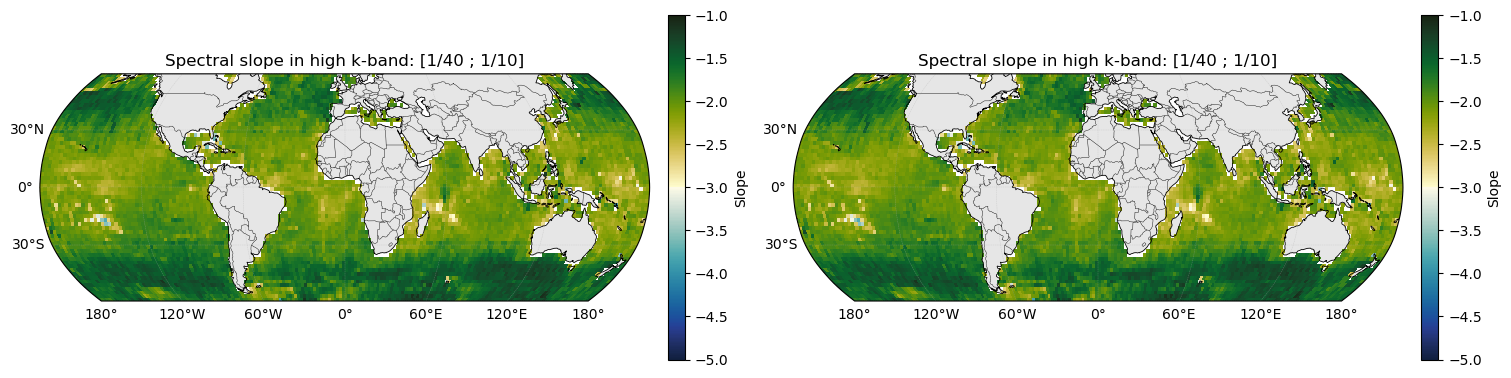

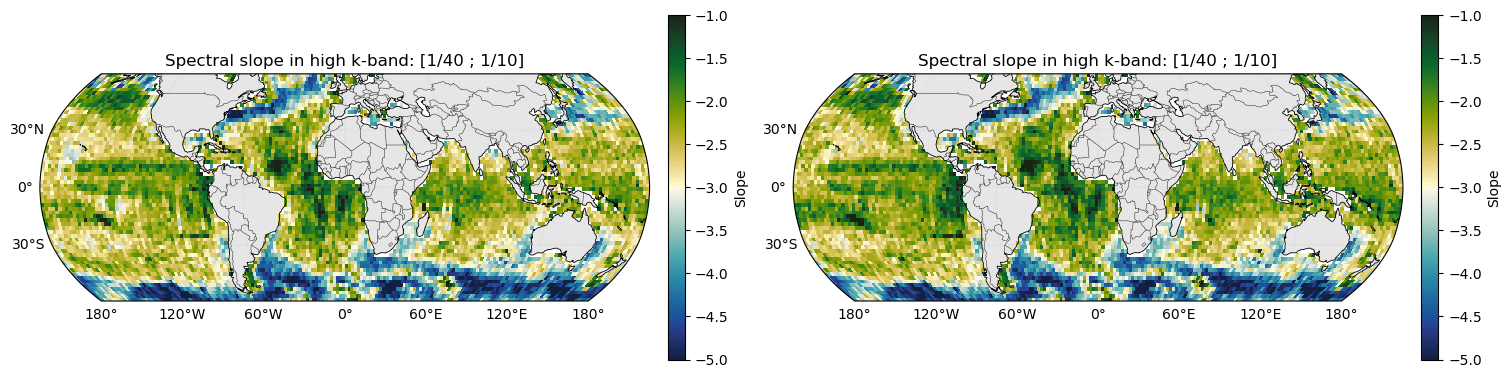

In [11]:
fig,axs = plt.subplots(1,2,figsize=(15,5),subplot_kw={"projection": ccrs.Robinson()},constrained_layout=True)
fig, ax = plot_box(ds_sep_adapt_itide.slope_high_k,
                   ds_sep_adapt_itide.lon_mean,ds_sep_adapt_itide.lat_mean, vmin=-5.0, vmax=-1.0,
                   title = r"Spectral slope in high k-band: [1/40 ; 1/10]", label=r'Slope',
                  cmap=cmocean.cm.delta, fig=fig,ax=axs[0])
ax.set_extent([-180,180,-60,60])
fig, ax = plot_box(ds_sep_adapt_notide.slope_high_k,
                   ds_sep_adapt_notide.lon_mean,ds_sep_adapt_notide.lat_mean, vmin=-5.0, vmax=-1.0,
                   title = r"Spectral slope in high k-band: [1/40 ; 1/10]", label=r'Slope',
                  cmap=cmocean.cm.delta, fig=fig,ax=axs[1])
ax.set_extent([-180,180,-60,60])

fig,axs = plt.subplots(1,2,figsize=(15,5),subplot_kw={"projection": ccrs.Robinson()},constrained_layout=True)
fig, ax = plot_box(ds_sep_adapt_itide.slope_low_k,
                   ds_sep_adapt_itide.lon_mean,ds_sep_adapt_itide.lat_mean, vmin=-5.0, vmax=-1.0,
                   title = r"Spectral slope in high k-band: [1/40 ; 1/10]", label=r'Slope',
                  cmap=cmocean.cm.delta, fig=fig,ax=axs[0])
ax.set_extent([-180,180,-60,60])
fig, ax = plot_box(ds_sep_adapt_notide.slope_low_k,
                   ds_sep_adapt_notide.lon_mean,ds_sep_adapt_notide.lat_mean, vmin=-5.0, vmax=-1.0,
                   title = r"Spectral slope in high k-band: [1/40 ; 1/10]", label=r'Slope',
                  cmap=cmocean.cm.delta, fig=fig,ax=axs[1])
ax.set_extent([-180,180,-60,60])

In [12]:
iseg = 10
ds10_itide = ds_itide.isel(segment=iseg)
ds10_notide = ds_notide.isel(segment=iseg)

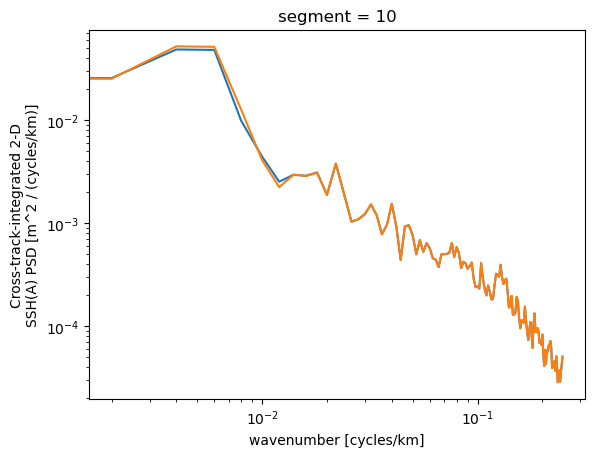

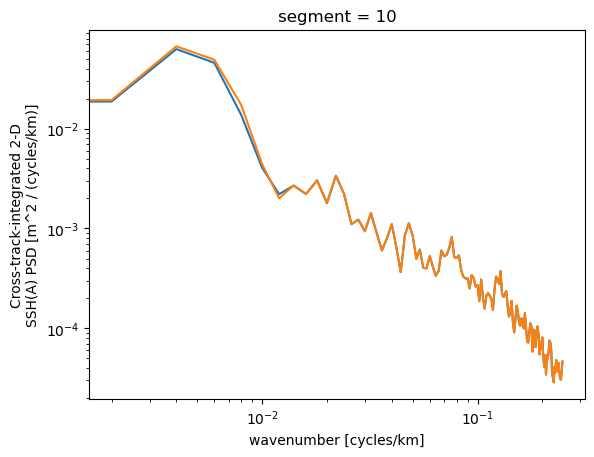

In [13]:
ds10_itide.psd.plot(xscale='log',yscale='log')
ds10_notide.psd.plot(xscale='log',yscale='log')

plt.figure()
ds10_itide.psd2D.plot(xscale='log',yscale='log')
ds10_notide.psd2D.plot(xscale='log',yscale='log')


## Spectral peaks identification

In [14]:
from scipy.signal import find_peaks
from scipy.stats import chi2


def detect_band_spectral_peak(ds_spectra: xr.Dataset,
                               psd_var: str = 'psd',
                               wavelength_band: tuple = (30, 50),
                               background_band: tuple = (15, 100),
                               dof: float = 4.0,
                               confidence: float = 0.95,
                               min_width_points: int = 4,
                               background_fit_min_points: int = 4,
                               verbose: bool = False) -> xr.Dataset:
    """
    Detect a significant spectral peak within a given wavelength band
    (default 30-50 km) for each segment's PSD, by comparing the band
    against a smooth power-law background fit from points just outside
    the band.

    Parameters
    ----------
    ds_spectra : xr.Dataset
        Must have psd_var with dims (segment, wavenumber) and a
        'wavenumber' coordinate in cycles/km.
    psd_var : str
        Name of the PSD variable.
    wavelength_band : tuple(float, float)
        (short, long) wavelength bounds in km to search for a peak,
        e.g. (30, 50).
    background_band : tuple(float, float)
        (short, long) wavelength bounds in km used to estimate the
        smooth background, excluding the peak band itself. Should be
        wider than wavelength_band on both sides, e.g. (15, 100).
    dof : float
        Effective degrees of freedom of each PSD estimate (2x the
        number of independent averages going into it, following the
        usual periodogram convention: dof=2 for a single raw segment
        estimate, larger if segments/cycles were already averaged).
        This sets the significance threshold via the chi-square
        distribution and should be adjusted to match your own
        processing (e.g. Hann-windowed, cross-track- and cycle-averaged
        spectra as in Zhang & Callies 2025 have much higher dof than 2).
    confidence : float
        Confidence level for the peak significance test (e.g. 0.95).
    min_width_points : int
        Minimum number of wavenumber bins inside the band required to
        attempt a peak-width estimate; below this, width is NaN.
    background_fit_min_points : int
        Minimum number of points needed on EACH side (low-k and high-k)
        of the band to fit the background; segments with fewer points
        are skipped.
    verbose : bool
        Print per-segment diagnostics.

    Returns
    -------
    xr.Dataset
        Copy of ds_spectra with added variables (dim 'segment'):
        - 'peak_found' (bool)
        - 'peak_wavelength' (km) -- NaN if not found
        - 'peak_wavenumber' (cycles/km)
        - 'peak_amplitude_ratio' -- PSD / background at the peak
        - 'peak_width' (km) -- NaN if not found or not enough points
        - 'peak_significance_threshold' -- the ratio threshold used
    """
    wavenumber = ds_spectra['wavenumber'].values
    psd_all = ds_spectra[psd_var].values  # (segment, wavenumber)
    n_segments = psd_all.shape[0]

    # Sort by wavenumber ascending (should already be, but be safe)
    order = np.argsort(wavenumber)
    wavenumber = wavenumber[order]
    psd_all = psd_all[:, order]
    log_k = np.log10(wavenumber)

    # Convert wavelength bounds (km) to wavenumber bounds (cycles/km)
    # Careful: short wavelength -> high wavenumber, so bounds flip.
    k_band_lo, k_band_hi = 1.0 / wavelength_band[1], 1.0 / wavelength_band[0]
    k_bg_lo, k_bg_hi = 1.0 / background_band[1], 1.0 / background_band[0]

    band_mask = (wavenumber >= k_band_lo) & (wavenumber <= k_band_hi)
    bg_low_mask = (wavenumber >= k_bg_lo) & (wavenumber < k_band_lo)
    bg_high_mask = (wavenumber > k_band_hi) & (wavenumber <= k_bg_hi)
    bg_fit_mask = bg_low_mask | bg_high_mask

    if band_mask.sum() < 1:
        raise ValueError("No wavenumber bins fall inside wavelength_band; "
                          "check units/bounds against ds_spectra['wavenumber'].")

    # Significance threshold: ratio of observed/expected PSD under H0
    # (pure background, no peak) follows chi2(dof)/dof.
    threshold = chi2.ppf(confidence, dof) / dof

    peak_found = np.zeros(n_segments, dtype=bool)
    peak_wavelength = np.full(n_segments, np.nan)
    peak_wavenumber = np.full(n_segments, np.nan)
    peak_ratio = np.full(n_segments, np.nan)
    peak_width = np.full(n_segments, np.nan)

    for i in range(n_segments):
        p = psd_all[i]
        valid = np.isfinite(p) & (p > 0)

        bg_idx = np.where(bg_fit_mask & valid)[0]
        band_idx = np.where(band_mask & valid)[0]

        if len(np.where(bg_low_mask & valid)[0]) < background_fit_min_points or \
           len(np.where(bg_high_mask & valid)[0]) < background_fit_min_points:
            if verbose:
                print(f"Segment {i}: insufficient background points on "
                      f"both sides, skipping.")
            continue
        if len(band_idx) < 1:
            continue

        # Fit smooth background: log-log linear fit using points OUTSIDE
        # the band only, so the peak itself can't bias its own baseline.
        slope, intercept = np.polyfit(log_k[bg_idx], np.log10(p[bg_idx]), 1)
        background_band_vals = 10 ** (slope * log_k[band_idx] + intercept)

        ratio = p[band_idx] / background_band_vals

        # Find local maxima in the ratio curve within the band.
        # Pad with neighbouring background points so a peak sitting near
        # the band edge can still be recognized as a local max.
        pad_left = np.where(bg_low_mask & valid)[0][-2:] if bg_low_mask.any() else np.array([], dtype=int)
        pad_right = np.where(bg_high_mask & valid)[0][:2] if bg_high_mask.any() else np.array([], dtype=int)
        ext_idx = np.concatenate([pad_left, band_idx, pad_right])
        ext_log_k = log_k[ext_idx]
        ext_bg = 10 ** (slope * ext_log_k + intercept)
        ext_ratio = p[ext_idx] / ext_bg

        peaks_idx, _ = find_peaks(ext_ratio)
        # Keep only peaks that (a) exceed the significance threshold and
        # (b) actually fall within the true band (not in the padding).
        band_start = len(pad_left)
        band_end = band_start + len(band_idx)
        candidate_peaks = [j for j in peaks_idx
                           if ext_ratio[j] > threshold
                           and band_start <= j < band_end]

        if len(candidate_peaks) == 0:
            if verbose:
                print(f"Segment {i}: no significant peak "
                      f"(max ratio in band = {ratio.max():.2f}, "
                      f"threshold = {threshold:.2f}).")
            continue

        # If multiple significant peaks, take the strongest one.
        j_best = max(candidate_peaks, key=lambda j: ext_ratio[j])

        # Sub-bin refinement via parabolic (quadratic) interpolation of
        # log(ratio) vs log(k) around the discrete maximum.
        if 0 < j_best < len(ext_ratio) - 1:
            x0, x1, x2 = ext_log_k[j_best - 1:j_best + 2]
            y0, y1, y2 = np.log10(ext_ratio[j_best - 1:j_best + 2])
            denom = (x0 - x1) * (x0 - x2) * (x1 - x2)
            if denom != 0:
                A = (x2 * (y1 - y0) + x1 * (y0 - y2) + x0 * (y2 - y1)) / denom
                B = (x2**2 * (y0 - y1) + x1**2 * (y2 - y0) + x0**2 * (y1 - y2)) / denom
                if A != 0:
                    log_k_peak = -B / (2 * A)
                    # Only trust the refinement if it stays within the
                    # local bracket; otherwise fall back to the raw bin.
                    if x0 <= log_k_peak <= x2:
                        k_peak = 10 ** log_k_peak
                    else:
                        k_peak = 10 ** ext_log_k[j_best]
                else:
                    k_peak = 10 ** ext_log_k[j_best]
            else:
                k_peak = 10 ** ext_log_k[j_best]
        else:
            k_peak = 10 ** ext_log_k[j_best]

        peak_found[i] = True
        peak_wavenumber[i] = k_peak
        peak_wavelength[i] = 1.0 / k_peak
        peak_ratio[i] = ext_ratio[j_best]

        # --- Peak width (only if enough points inside the band) ---
        if len(band_idx) >= min_width_points:
            half_level = 1.0 + (ext_ratio[j_best] - 1.0) / 2.0
            # Search left and right from the peak for the half-max crossing
            left = j_best
            while left > 0 and ext_ratio[left] > half_level:
                left -= 1
            right = j_best
            while right < len(ext_ratio) - 1 and ext_ratio[right] > half_level:
                right += 1

            if ext_ratio[left] <= half_level and ext_ratio[right] <= half_level \
               and left < j_best < right:
                # Linear interpolation in log-k space for each crossing
                frac_l = (half_level - ext_ratio[left]) / (ext_ratio[left + 1] - ext_ratio[left])
                log_k_left = ext_log_k[left] + frac_l * (ext_log_k[left + 1] - ext_log_k[left])
                frac_r = (ext_ratio[right - 1] - half_level) / (ext_ratio[right - 1] - ext_ratio[right])
                log_k_right = ext_log_k[right - 1] + frac_r * (ext_log_k[right] - ext_log_k[right - 1])

                k_left, k_right = 10 ** log_k_left, 10 ** log_k_right
                wl_left, wl_right = 1.0 / k_left, 1.0 / k_right
                peak_width[i] = abs(wl_left - wl_right)
            elif verbose:
                print(f"Segment {i}: peak found but half-max crossings "
                      f"not bracketed, width left as NaN.")
        elif verbose:
            print(f"Segment {i}: only {len(band_idx)} points in band "
                  f"(< {min_width_points}), width left as NaN.")

    ds_out = ds_spectra.copy()
    ds_out['peak_found'] = ('segment', peak_found)
    ds_out['peak_wavelength'] = (
        'segment', peak_wavelength,
        {'long_name': f'Peak wavelength in {wavelength_band} km band', 'units': 'km'}
    )
    ds_out['peak_wavenumber'] = (
        'segment', peak_wavenumber,
        {'long_name': 'Peak wavenumber', 'units': 'cycles/km'}
    )
    ds_out['peak_amplitude_ratio'] = (
        'segment', peak_ratio,
        {'long_name': 'PSD at peak / local background PSD'}
    )
    ds_out['peak_width'] = (
        'segment', peak_width,
        {'long_name': 'Peak full width at half-maximum (above background)', 'units': 'km'}
    )
    ds_out.attrs['peak_detection_dof'] = dof
    ds_out.attrs['peak_detection_confidence'] = confidence
    ds_out.attrs['peak_detection_threshold'] = threshold

    return ds_out

In [15]:
ds_peaks = detect_band_spectral_peak(
    ds_itide,
    psd_var='psd',
    wavelength_band=(20, 50),
    background_band=(10, 150),
    dof=250.0,          # <-- adjust to match your actual spectral averaging
    confidence=0.95,
    min_width_points=5,
    verbose=False,
)

# Then, to look at the along-track evolution from Amazon to 30°N:
evolution = ds_peaks[['peak_wavelength', 'peak_width', 'peak_found']].where(
    ds_peaks['peak_found']
)

/var/folders/fv/pmf052vs1g77j8b23nzvlkmm0000gr/T/ipykernel_14215/1657652029.py:74: RuntimeWarning: divide by zero encountered in log10
  log_k = np.log10(wavenumber)


In [16]:
latitudes = ds_itide.sel(segment=evolution.segment).lat_mean
longitudes = ds_itide.sel(segment=evolution.segment).lon_mean
longitudes

<xarray.DataArray 'lon_mean' (segment: 706859)> Size: 6MB
array([249.334968, 249.717995, 250.090225, ..., 297.732849, 304.009226,
       305.527527], shape=(706859,))
Coordinates:
  * segment  (segment) int64 6MB 0 1 2 3 4 ... 706855 706856 706857 706858
Attributes:
    units:    degrees_east

In [17]:
def build_box_general(ds_segments: xr.Dataset,
                      box_deg: float = 2.0,
                      var: str = 'psd',
                      lat: np.array = None,
                      lon: np.array = None,
                      min_sampling_fraction: float = 0.5) -> xr.Dataset:
    from collections import defaultdict
    if lat is None:
        lat     = ds_segments['lat_mean'].values
        lon     = ds_segments['lon_mean'].values
    lat_idx = np.floor(lat / box_deg).astype(int)
    lon_idx = np.floor(lon / box_deg).astype(int)
    box_to_segs = defaultdict(list)
    for i, key in enumerate(zip(lat_idx, lon_idx)):
        box_to_segs[key].append(i)
    psd_all    = ds_segments[var].values
    rows_lat, rows_lon, rows_n, rows_psd = [], [], [], []
    for (li, loi), idxs in sorted(box_to_segs.items()):
        if 'wavenumber' in ds_segments.coords.keys():
            rows_psd.append(np.nanmean(psd_all[idxs, :], axis=0))
        else:
            rows_psd.append(np.nanmean(psd_all[idxs]))
        rows_n.append(len(idxs))
        rows_lat.append((li  + 0.5) * box_deg)
        rows_lon.append((loi + 0.5) * box_deg)
    n_segments = np.array(rows_n)
    n_max      = n_segments.max()
    keep       = n_segments >= min_sampling_fraction * n_max
    if 'wavenumber' in ds_segments.coords.keys():
        psd_stack  = np.stack(rows_psd, axis=0)
    else:
        psd_stack  = np.array(rows_psd)
    lat_mean   = np.array(rows_lat)
    lon_mean   = np.array(rows_lon)
    if 'wavenumber' in ds_segments.coords.keys():
        wavenumber = ds_segments['wavenumber'].values
        return xr.Dataset(
            data_vars=dict(
                mean_psd=(['box', 'wavenumber'], psd_stack[keep],
                          {'long_name': 'Box-mean SSH(A) PSD', 'units': 'm^2 / (cycles/km)'}),
                n_segments=(['box'], n_segments[keep]),
                sampling_fraction=(['box'], n_segments[keep] / n_max),
            ),
            coords=dict(wavenumber=('wavenumber', wavenumber, {'units': 'cycles/km'}),
                box=('box', np.arange(keep.sum())),
                lat_mean=('box', lat_mean[keep], {'units': 'degrees_north'}),
                lon_mean=('box', lon_mean[keep], {'units': 'degrees_east'}),
            ),
            attrs=dict(box_size_deg=box_deg,
                       min_sampling_fraction=min_sampling_fraction),
        )
    else:
        return xr.Dataset(
                data_vars=dict(
                    mean=(['box'], psd_stack[keep],
                              {'long_name': 'Box-mean'}),
                    n_segments=(['box'], n_segments[keep]),
                    sampling_fraction=(['box'], n_segments[keep] / n_max),
                ),
                coords=dict(box=('box', np.arange(keep.sum())),
                    lat_mean=('box', lat_mean[keep], {'units': 'degrees_north'}),
                    lon_mean=('box', lon_mean[keep], {'units': 'degrees_east'}),
                ),
                attrs=dict(box_size_deg=box_deg,
                           min_sampling_fraction=min_sampling_fraction),
            )

In [18]:
boxes_peaks = build_box_general(evolution,box_deg = BOX_DEG, lat=latitudes.values,lon=longitudes.values,
                                var='peak_wavelength',min_sampling_fraction=0.15)

/var/folders/fv/pmf052vs1g77j8b23nzvlkmm0000gr/T/ipykernel_14215/626618433.py:22: RuntimeWarning: Mean of empty slice
  rows_psd.append(np.nanmean(psd_all[idxs]))


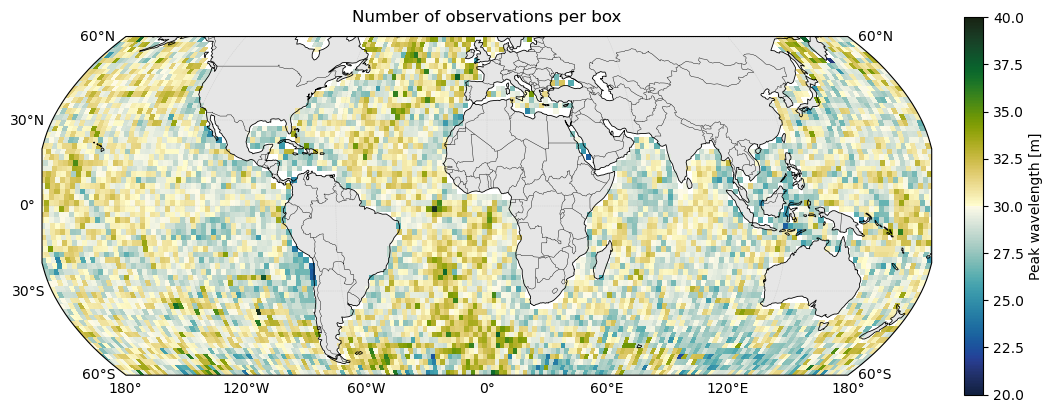

In [19]:
fig, ax = plot_box(boxes_peaks['mean'],boxes_peaks["lon_mean"].values,boxes_peaks["lat_mean"].values,
                   cmap=cmocean.cm.delta, vmin = 20, vmax=40,
                    label='Peak wavelength [m]')
ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())

plt.show()

In [20]:
small_scales = ds_itide.where(evolution.peak_wavelength<=30,drop=True)

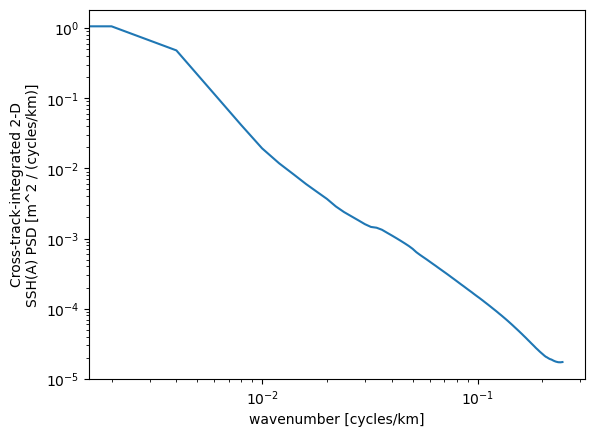

In [21]:

small_scales.psd.mean('segment').plot(xscale='log',yscale='log')

## Spectral evolution from Amazon shelf t to 30°N

In [102]:
amazon_itide = ds_itide.where((ds_itide.lat_mean<=35) &(ds_itide.lat_mean>=-5) & (ds_itide.lon_mean<=350) & (ds_itide.lon_mean>=280),drop=True)
amazon_notide = ds_notide.where((ds_itide.lat_mean<=35) &(ds_itide.lat_mean>=-5) & (ds_itide.lon_mean<=350) & (ds_itide.lon_mean>=280),drop=True)

In [103]:
boxes_amazoni = build_box_general(amazon_itide,box_deg = BOX_DEG,min_sampling_fraction=0.15)


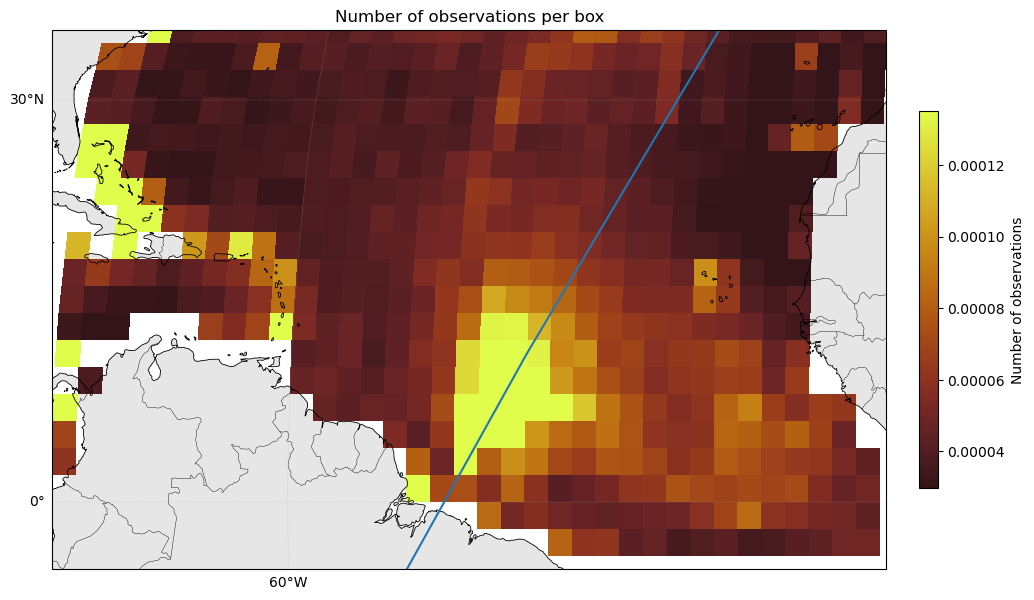

In [104]:
energy = boxes_amazoni.mean_psd.sel(wavenumber=slice(1/50,1/10)).integrate('wavenumber')
fig,ax = plot_box(energy,
                  boxes_amazoni.lon_mean, boxes_amazoni.lat_mean,
                 cmap=cmocean.cm.solar,vmin=np.nanpercentile(energy,5), vmax=np.nanpercentile(energy,95))
ax.set_extent([-80,-10,-5,35],crs=ccrs.PlateCarree())
#ax.plot([-55,-45],[4,35],transform=ccrs.PlateCarree())
#ax.plot([-35,-25],[-5,35],transform=ccrs.PlateCarree())
line = ax.plot([-50,-25],[-5,35],transform=ccrs.PlateCarree())

In [105]:
lats = np.array([-5.0,35.0])*np.pi/180
lons = np.array([-50.0,-25.0])*np.pi/180
X = np.cos(lats) * np.cos(lons)
Y = np.sin(lats)
Z = np.sin(lons) * np.cos(lats)

#for the Nth point in a set that divides the path into D segments (and yields S-1 points not counting the start and end points) M = N/D
#For the starting point (A) M=0
#For the ending point (B) M=1


In [155]:
X_points, Y_points, Z_points = [],[],[]
for M in np.linspace(0,1,10):
    X_points.append((X[-1] - X[0]) * M + X[0])
    Y_points.append((Y[-1] - Y[0]) * M + Y[0])
    Z_points.append((Z[-1] - Z[0]) * M + Z[0])
#Step 3: Project the interpolated points up to the surface of the Unit Sphere.
Xs, Ys, Zs = [], [], []
for i in range(len(X_points)):
    Xs.append(X_points[i] / np.sqrt(X_points[i]**2 + Y_points[i]**2 + Z_points[i]**2))
    Ys.append(Y_points[i] / np.sqrt(X_points[i]**2 + Y_points[i]**2 + Z_points[i]**2))
    Zs.append(Z_points[i] / np.sqrt(X_points[i]**2 + Y_points[i]**2 + Z_points[i]**2))
#Step 4: Convert back to latitude and longitude.
Lat, Lon = [], []
for i in range(len(Zs)):
    Lon.append(np.arctan(Z_points[i]/X_points[i])*180/np.pi+360)
    Lat.append(np.arcsin(Y_points[i])*180/np.pi)


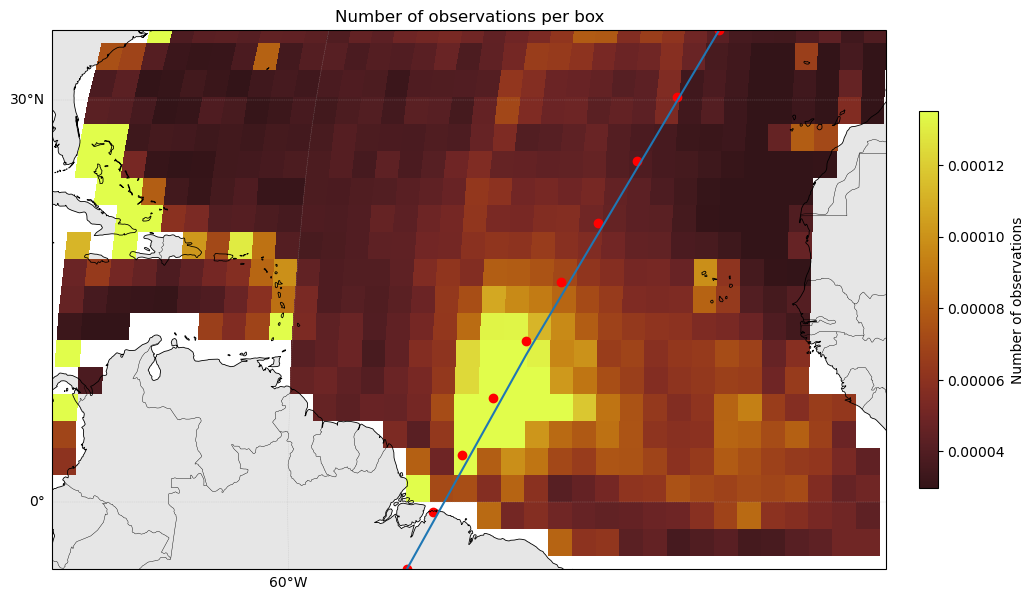

In [156]:
energy = boxes_amazoni.mean_psd.sel(wavenumber=slice(1/50,1/10)).integrate('wavenumber')
fig,ax = plot_box(energy,
                  boxes_amazoni.lon_mean, boxes_amazoni.lat_mean,
                 cmap=cmocean.cm.solar,vmin=np.nanpercentile(energy,5), vmax=np.nanpercentile(energy,95))
ax.set_extent([-80,-10,-5,35],crs=ccrs.PlateCarree())
#ax.plot([-55,-45],[4,35],transform=ccrs.PlateCarree())
#ax.plot([-35,-25],[-5,35],transform=ccrs.PlateCarree())
line = ax.plot([-50,-25],[-5,35],transform=ccrs.PlateCarree())
for i in range(len(Lat)):
    ax.scatter(Lon[i], Lat[i],transform=ccrs.PlateCarree(),c='r')

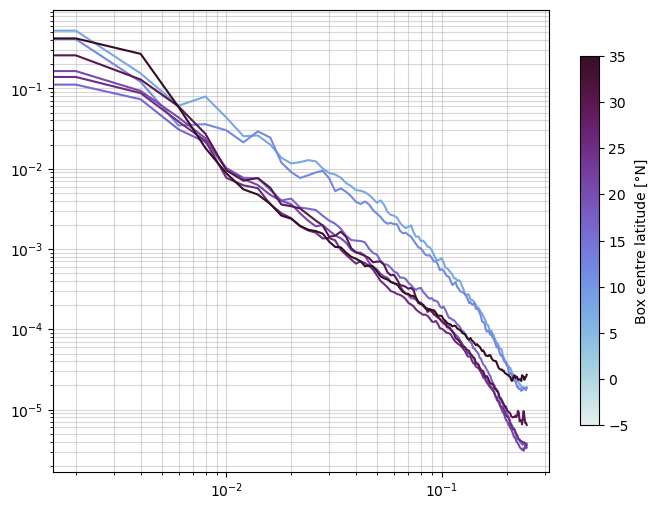

In [161]:
dlat, dlon=1.0, 1.0
norm = plt.Normalize(vmin=np.min(Lat[:]), vmax=np.max(Lat[3:]))
cmap = plt.get_cmap(cmocean.cm.dense)
fig,ax = plt.subplots(figsize=(8,6))
for i in np.arange(3,len(Lon)):
    _ = boxes_amazoni.where((boxes_amazoni.lat_mean<=Lat[i]+dlat) & (boxes_amazoni.lat_mean>=Lat[i]-dlat) &
                        (boxes_amazoni.lon_mean<=Lon[i]+dlon) & (boxes_amazoni.lon_mean>=Lon[i]-dlon),drop=True)
    ax.loglog(_.wavenumber,_.mean_psd[0,:],c=cmap(norm(Lat[i])))
ax.grid(True,which='both',alpha=0.5)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Box centre latitude [°N]",shrink=0.8)